In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

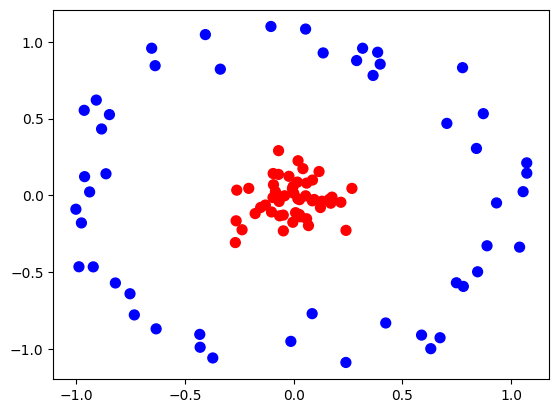

In [3]:
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='bwr')

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

In [5]:
classifier = SVC(kernel="linear")
classifier.fit(X_train, y_train.ravel())
y_pred = classifier.predict(X_test)

In [6]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.65

In [7]:
zero_one_colourmap = ListedColormap(('blue', 'red'))
def plot_decision_boundary(X, y, clf):
    X_set, y_set = X, y
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, 
                                 stop = X_set[:, 0].max() + 1, 
                                 step = 0.01),
                       np.arange(start = X_set[:, 1].min() - 1, 
                                 stop = X_set[:, 1].max() + 1, 
                                 step = 0.01))
  
    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(), 
                                             X2.ravel()]).T).reshape(X1.shape),
               alpha = 0.75, 
               cmap = zero_one_colourmap)
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = (zero_one_colourmap)(i), label = j)
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()

C:\Users\Nandika\AppData\Local\Temp\ipykernel_16332\3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


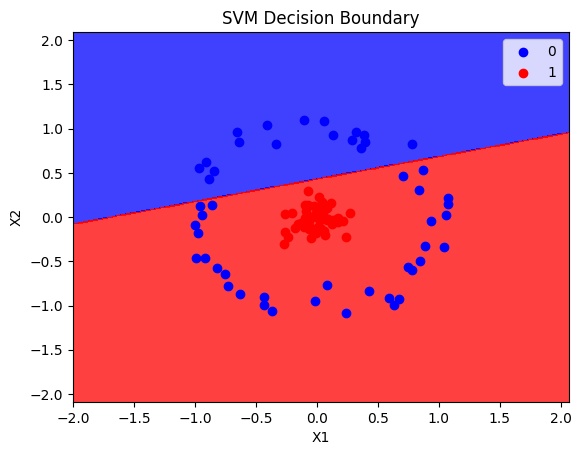

In [9]:
plot_decision_boundary(X, y, classifier)

In [10]:
def plot_3d_plot(X, y):
    r = np.exp(-(X ** 2).sum(1))
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=100, cmap='bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    return ax

<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

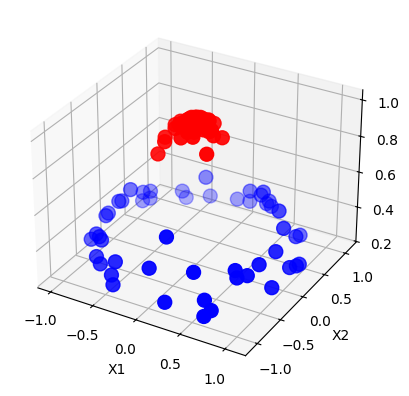

In [11]:
plot_3d_plot(X,y)

In [12]:
rbf_classifier = SVC(kernel="rbf")
rbf_classifier.fit(X_train, y_train)
y_pred = rbf_classifier.predict(X_test)

In [13]:
accuracy_score(y_test, y_pred)

1.0

C:\Users\Nandika\AppData\Local\Temp\ipykernel_16332\3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


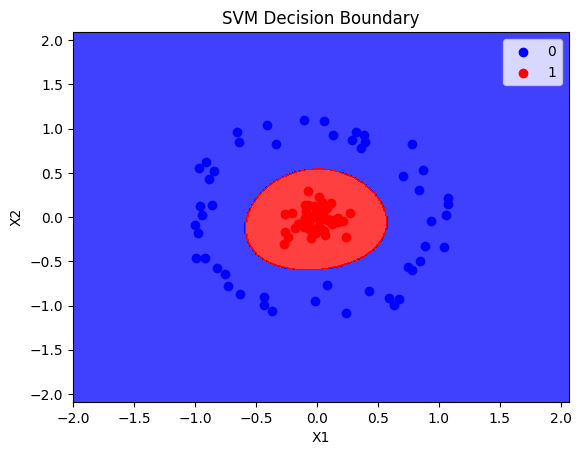

In [14]:
plot_decision_boundary(X, y, rbf_classifier)

In [15]:
poly_classifier = SVC(kernel="poly",degree=2)
poly_classifier.fit(X_train, y_train)
y_pred = poly_classifier.predict(X_test)

In [16]:
accuracy_score(y_test, y_pred)

1.0

C:\Users\Nandika\AppData\Local\Temp\ipykernel_16332\3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


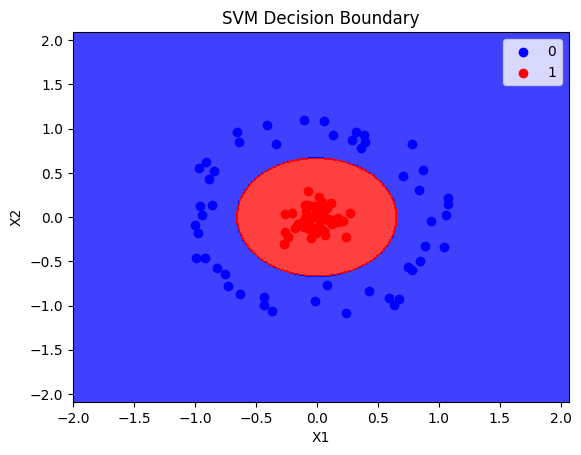

In [17]:
plot_decision_boundary(X, y, poly_classifier)

In [18]:
X

array([[-4.31660243e-01, -9.04873361e-01],
       [ 1.95328089e-02, -2.21666985e-02],
       [ 1.35994034e-01,  9.27207916e-01],
       [ 7.05124487e-01,  4.68503199e-01],
       [ 2.68347452e-01,  4.53876497e-02],
       [ 1.07268529e+00,  2.11598704e-01],
       [ 1.30216805e-01, -3.80300382e-02],
       [ 5.54493085e-02, -2.88357955e-03],
       [-3.37115298e-01,  8.21404464e-01],
       [ 8.67936953e-02,  9.97655202e-02],
       [-7.52699589e-01, -6.40387679e-01],
       [-4.29997378e-01, -9.88621679e-01],
       [ 1.05597134e+00,  2.40369662e-02],
       [-4.05962347e-01,  1.04654508e+00],
       [ 4.29051202e-02,  1.73970708e-01],
       [ 1.76668884e-01, -1.15188957e-02],
       [ 8.72818688e-01,  5.31881504e-01],
       [ 8.53441759e-02, -7.69958323e-01],
       [-3.61862167e-03, -1.75072533e-01],
       [ 3.86727272e-01,  9.31568616e-01],
       [ 2.89958637e-01,  8.77529408e-01],
       [ 2.41068165e-01, -2.27793175e-01],
       [ 2.40667518e-01, -1.08772171e+00],
       [ 6.

In [19]:
np.exp(-(X**2)).sum(1)

array([1.27096152, 1.9991273 , 1.4049585 , 1.41115497, 1.92846334,
       1.27264339, 1.9817413 , 1.99692178, 1.40187972, 1.98259137,
       1.23106238, 1.20748768, 1.32731292, 1.18251247, 1.96834846,
       1.96913749, 1.22041627, 1.54550037, 1.96980147, 1.28095433,
       1.38234765, 1.89297606, 1.25004049, 1.05879027, 1.99848356,
       1.04758764, 1.89643626, 1.29558026, 1.95177641, 1.9900762 ,
       1.96263064, 1.99286693, 1.41396714, 1.90539612, 1.97808727,
       1.04086426, 1.05237157, 1.97980074, 1.98425799, 1.99980109,
       1.38182261, 1.35852859, 1.99826719, 1.41855662, 1.97931324,
       1.95003664, 1.94576823, 1.97277682, 1.45504765, 1.95620732,
       1.29401778, 1.95735859, 1.19710032, 1.95526864, 1.26914173,
       1.30675339, 1.28781194, 1.24722725, 1.2328665 , 1.93272689,
       1.23185754, 1.40366309, 1.99667834, 1.98140095, 1.99243207,
       1.97109993, 1.35384617, 1.84059964, 1.18278702, 1.98726989,
       1.14041102, 1.99135714, 1.41580918, 1.24629669, 1.99802

In [20]:
X_new=np.exp(-(X**2))

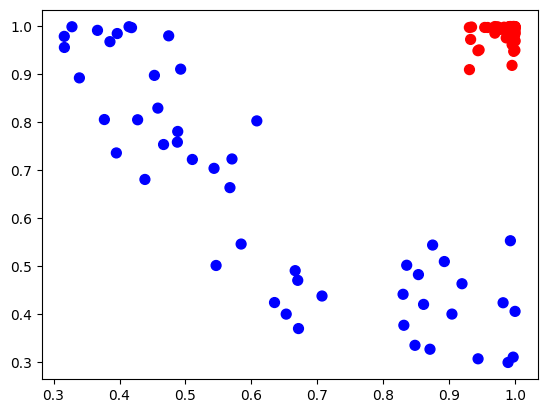

In [21]:
plt.scatter(X_new[:, 0], X_new[:, 1], c=y, s=50, cmap='bwr')